<a href="https://colab.research.google.com/github/Code-eram/skills-introduction-to-github/blob/main/Copy_of_Aerofit_pdf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [ ]:
# uploading the Aerofit dataset
df=pd.read_csv('aerofit_treadmill.csv')

In [ ]:
# To view the data, we take some random 10 samples that will help in data understanding
df.sample(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
97,KP481,25,Female,14,Partnered,2,3,45480,85
155,KP781,25,Male,18,Partnered,6,5,75946,240
65,KP281,35,Female,18,Single,3,3,67083,85
15,KP281,23,Male,16,Partnered,3,3,40932,75
52,KP281,29,Female,16,Partnered,4,3,50028,94
12,KP281,22,Female,16,Single,4,3,36384,75
91,KP481,23,Female,16,Partnered,3,2,43206,74
32,KP281,25,Female,16,Partnered,2,2,40932,47
18,KP281,23,Female,16,Single,4,3,38658,113
23,KP281,24,Female,16,Partnered,5,5,44343,188


In [ ]:
# Performing Exploratory Data Analysis
print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nDescription:")
display(df.describe())

print("\nNull Values:")
print(df.isnull().sum())

print("\nColumn Types:")
print(df.dtypes)


Shape:
(180, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB

Description:


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000



Null Values:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Column Types:
Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object


<Axes: >

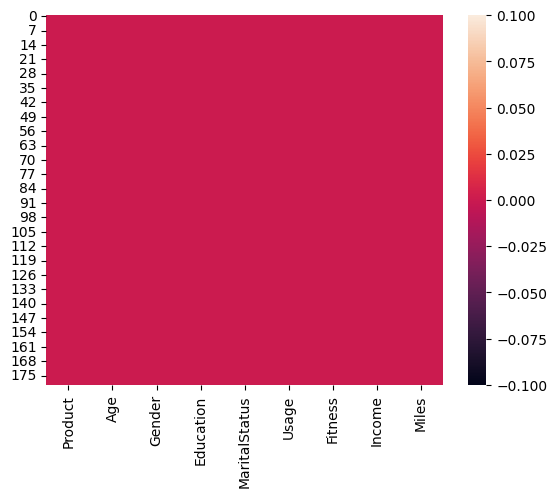

In [ ]:
# This can be further checked using a heatmap to see if any null values are present.
sns.heatmap(df.isnull())

In [ ]:
# Finding out all the unique products available
unique_product=df['Product'].value_counts()

In [ ]:
unique_product

,count
Product,
KP281,80
KP481,60
KP781,40


In [ ]:
# Here segregating all the products with their corresponding columns , this will help analysing each product better.
prod_KP281=df[df['Product'] == 'KP281']
prod_KP481=df[df['Product'] == 'KP481']
prod_KP781=df[df['Product'] == 'KP781']


In [ ]:
# Finding out the probabilities of each product present will help us know which is the most purchased.
prob_KP281 = len(prod_KP281) / len(df)
prob_KP481 = len(prod_KP481) / len(df)
prob_KP781 = len(prod_KP781) / len(df)

print('KP281=',f"{prob_KP281:.3f},",'KP481=', f"{prob_KP481:.3f},", 'KP781=',f"{prob_KP781:.3f}")

KP281= 0.444, KP481= 0.333, KP781= 0.222


##**KP281**

In [ ]:
# Check the shape of the prod_KP281 DataFrame
prod_KP281.shape

(80, 9)

In [ ]:
prod_KP281.sample(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
71,KP281,38,Male,16,Partnered,3,3,56850,75
53,KP281,30,Male,14,Partnered,4,4,46617,141
57,KP281,32,Female,14,Single,3,4,46617,113
21,KP281,23,Male,16,Single,4,3,40932,94
54,KP281,30,Male,14,Single,3,3,54576,85
28,KP281,25,Male,14,Partnered,2,3,45480,56
38,KP281,26,Female,16,Single,3,3,36384,66
72,KP281,39,Male,16,Partnered,4,4,59124,132
6,KP281,21,Female,14,Partnered,3,3,35247,75
58,KP281,32,Male,14,Partnered,4,3,52302,85


In [ ]:
# Total Count of Gender.
prod_KP281['Gender'].value_counts()

,count
Gender,
Male,40
Female,40


In [ ]:
# Finding the probability of each gender
prob_male_purchase_prod_KP281=prod_KP281['Gender'].value_counts().loc['Male']/len(prod_KP281)
prob_female_purchase_prod_KP281=1-prob_male_purchase_prod_KP281
print('Probability of male that purchased KP281 : ',prob_male_purchase_prod_KP281)
print('Probability of female that purchased KP281 : ',prob_female_purchase_prod_KP281)

Probability of male that purchased KP281 :  0.5
Probability of female that purchased KP281 :  0.5


In [ ]:
# grouping age
prod_KP281.loc[:, 'age_group'] = pd.cut(prod_KP281['Age'], bins=bins, labels=labels, right=False)

In [ ]:
# using pandas crosstab
pd.crosstab(index=prod_KP281['Gender'], columns=prod_KP281['age_group'])


age_group,0-20,21-30,31-40,41-50,51-60
Gender,,,,,
Female,1,27,9,2,1
Male,3,22,11,4,0


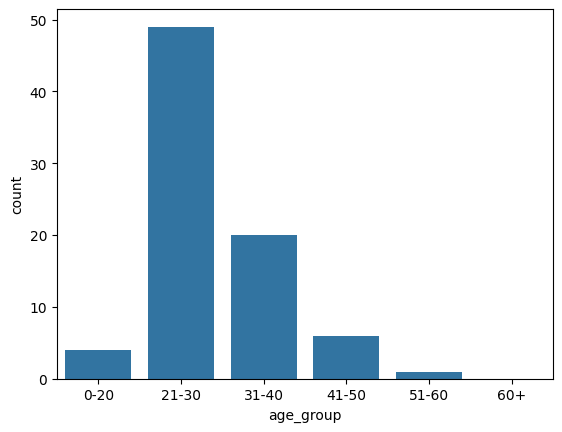

In [ ]:
# This can be visually seen using a  countplot, the range of the age group.
sns.countplot(x='age_group', data=prod_KP281)
plt.show()

In [ ]:
#probability of most age group.
age_bins = pd.cut(prod_KP281['Age'], bins=[20, 30, 40, 50, 60])
age_counts = age_bins.value_counts().sort_index()
max_group_281 = age_counts.idxmax()
max_count = age_counts.max()
prob_age_281 = max_count / len(prod_KP281)

print(f"The most common age group is {max_group_281}, with probability {prob_age_281:.2f}")


The most common age group is (20, 30], with probability 0.61


In [ ]:
# Total count of Marital status.
prod_KP281['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,48
Single,32


In [ ]:
# Probability of marital status
prob_partnered_KP281=prod_KP281['MaritalStatus'].value_counts().loc['Partnered']/len(prod_KP281)
prob_single_KP281=1-prob_partnered_KP281
print('Probability of people using KP281 and are married : ',prob_partnered_KP281)
# prob_single=1-prob_partnered
print('Probability of people using KP281 and are single : ',prob_single_KP281)

Probability of people using KP281 and are married :  0.6
Probability of people using KP281 and are single :  0.4


In [ ]:
# Max count, the number of times people use per week.
prod_KP281['Usage'].value_counts()

,count
Usage,
3,37
4,22
2,19
5,2


In [ ]:
# Average number of times it is used in a week
print('max count of usage',prod_KP281['Usage'].mode())
print('Average time people use : ',prod_KP281['Usage'].mean())

max count of usage 0    3
Name: Usage, dtype: int64
Average time people use :  3.0875


In [ ]:
prod_KP281['Income'].value_counts()

,count
Income,
46617,7
54576,7
52302,6
45480,5
35247,5
44343,4
40932,4
38658,3
51165,3


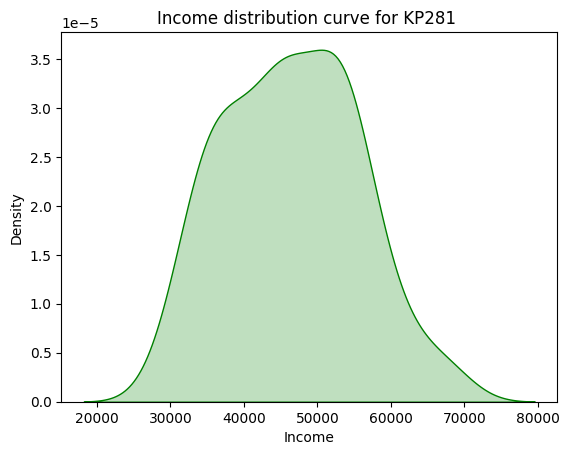

In [ ]:
# Plotting most People who purchased this, bare annual income.
raw_data = prod_KP281['Income'].value_counts().index.repeat(prod_KP281['Income'].value_counts().values)
sns.kdeplot(raw_data, fill=True,color='green')
plt.title('Income distribution curve for KP281 ')
plt.xlabel('Income')
plt.ylabel('Density')
plt.show()

In [ ]:
# Most rated fitness among users
prod_KP281['Fitness'].value_counts()
print('The average Fitness : ',prod_KP281['Fitness'].mean())
print('The maximun fitness among users : ',prod_KP281['Fitness'].mode())

The average Fitness :  2.9625
The maximun fitness among users :  0    3
Name: Fitness, dtype: int64


In [ ]:
Miles_281=prod_KP281['Miles'].value_counts()

In [ ]:
print('The mean of Miles covered in a week : ',prod_KP281['Miles'].mean())
print('The max number of Miles covered in a week by most users : ',prod_KP281['Miles'].mode())

The mean of Miles covered in a week :  82.7875
The max number of Miles covered in a week by most users :  0    85
Name: Miles, dtype: int64


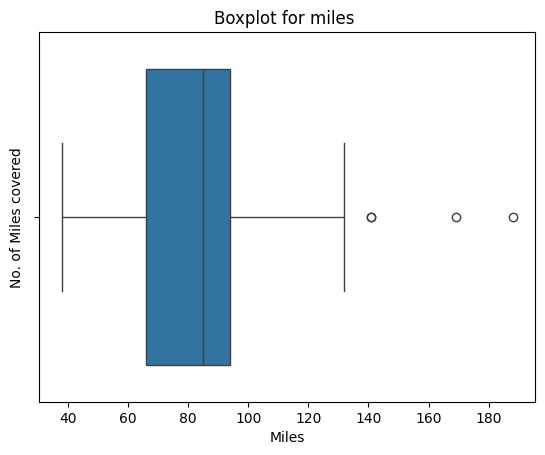

In [ ]:
sns.boxplot(x='Miles',  data=prod_KP281)
plt.title('Boxplot for miles ')
plt.xlabel('Miles')
plt.ylabel('No. of Miles covered')
plt.show()


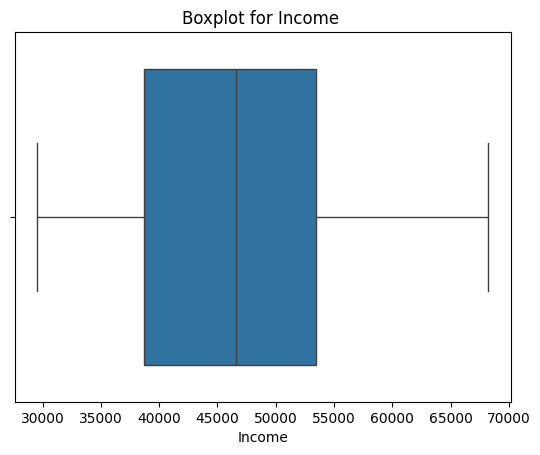

In [ ]:
sns.boxplot(x='Income',  data=prod_KP281)
plt.title('Boxplot for Income ')
plt.xlabel('Income')
# plt.ylabel('No. of Miles covered')
plt.show()


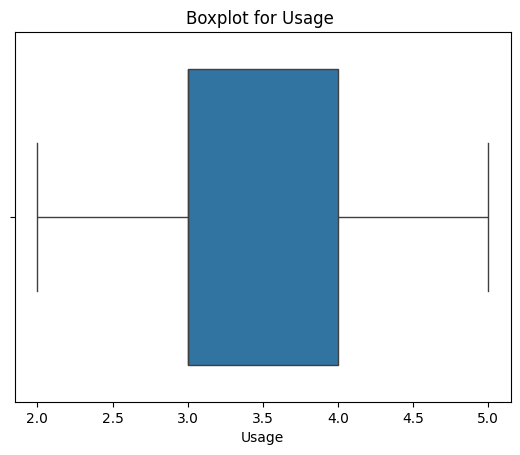

In [ ]:
sns.boxplot(x='Usage',  data=prod_KP281)
plt.title('Boxplot for Usage ')
plt.xlabel('Usage')
# plt.ylabel('No. of Miles covered')
plt.show()


###**Observations of Model KP281:**

*   Around 44% of people use this Product model KP281
*   In which , the probability of male and female using it is same which is 0.5.
*   This model is widely used by the age group (20-30), we can see this is
    popular among the Young Adults, holding 60% of the data.
*   60% of the users who bought this are married .
*   Their maximun usage is around 3 times per week , which is also the average
    number of times used.
*   The people who bought this have annual income mostly in the range(40,000-60,000).
*   They rate themselves 3 in the fitness scale 0f 1-5, which is moderately fit.
*   Their average miles covered is 82.7 , while most people cover 85 miles per week.










##**KP481**

In [ ]:
# Check the shape of the prod_KP481 DataFrame
prod_KP481.shape

(60, 9)

In [ ]:
prod_KP481.sample(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,age_group
97,KP481,25,Female,14,Partnered,2,3,45480,85,21-30
118,KP481,32,Male,16,Single,4,3,60261,127,31-40
87,KP481,23,Male,14,Partnered,3,3,36384,95,21-30
116,KP481,31,Female,16,Partnered,2,3,51165,64,31-40
130,KP481,35,Female,16,Single,3,2,50028,64,31-40
81,KP481,20,Male,14,Single,2,3,32973,53,21-30
113,KP481,30,Female,14,Single,3,3,57987,74,31-40
91,KP481,23,Female,16,Partnered,3,2,43206,74,21-30
112,KP481,29,Female,14,Partnered,3,3,51165,95,21-30
100,KP481,25,Female,14,Partnered,5,3,47754,106,21-30


In [ ]:
prod_KP481['Gender'].value_counts()

,count
Gender,
Male,31
Female,29


In [ ]:
# Finding the probability of each gender
prob_male_purchase_prod_KP481=prod_KP481['Gender'].value_counts().loc['Male']/len(prod_KP481)
prob_female_purchase_prod_KP481=1-prob_male_purchase_prod_KP481
print('Probability of male that purchased KP481 : ',prob_male_purchase_prod_KP481)
print('Probability of female that purchased KP481 : ',prob_female_purchase_prod_KP481)

Probability of male that purchased KP481 :  0.5166666666666667
Probability of female that purchased KP481 :  0.4833333333333333


In [ ]:
# grouping age
prod_KP481.loc[:, 'age_group'] = pd.cut(prod_KP481['Age'], bins=bins, labels=labels, right=False)

In [ ]:
# using pandas crosstab
pd.crosstab(index=prod_KP481['Gender'], columns=prod_KP481['age_group'])


age_group,0-20,21-30,31-40,41-50
Gender,,,,
Female,0,15,12,2
Male,1,17,10,3


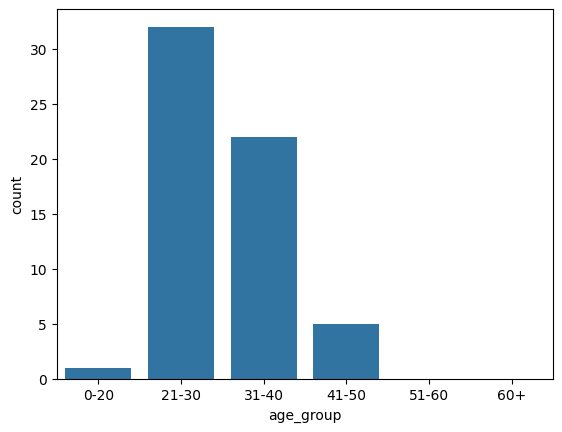

In [ ]:
# This can be visually seen using a  countplot, the range of the age group.
sns.countplot(x='age_group', data=prod_KP481)
plt.show()

In [ ]:
#probability of most age group using it
age_bins = pd.cut(prod_KP481['Age'], bins=[20, 30, 40, 50])
age_counts = age_bins.value_counts().sort_index()
max_group = age_counts.idxmax()
max_count = age_counts.max()
prob = max_count / len(prod_KP481)

print(f"The most common age group is {max_group}, with probability {prob:.2f}")


The most common age group is (20, 30], with probability 0.52


In [ ]:
prod_KP481['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,36
Single,24


In [ ]:
# Probability of marital status
prob_partnered_KP481=prod_KP481['MaritalStatus'].value_counts().loc['Partnered']/len(prod_KP481)
prob_single_KP481=1-prob_partnered_KP481
print('Probability of people using KP281 and are married : ',prob_partnered_KP481)
# prob_single=1-prob_partnered
print('Probability of people using KP281 and are single : ',prob_single_KP481)

Probability of people using KP281 and are married :  0.6
Probability of people using KP281 and are single :  0.4


In [ ]:
prod_KP481['Usage'].value_counts()

,count
Usage,
3,31
2,14
4,12
5,3


In [ ]:
# Average number of times it is used in a week
print('max count of usage',prod_KP481['Usage'].mode())
print('Average time people use : ',prod_KP481['Usage'].mean())

max count of usage 0    3
Name: Usage, dtype: int64
Average time people use :  3.066666666666667


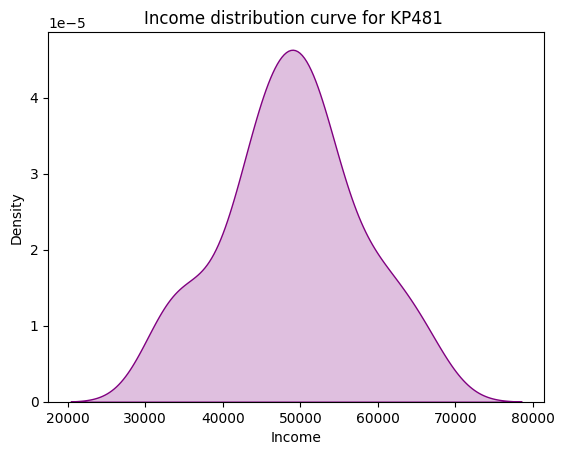

In [ ]:
prod_KP481['Income'].value_counts()
raw_data = prod_KP481['Income'].value_counts().index.repeat(prod_KP481['Income'].value_counts().values)
sns.kdeplot(raw_data, fill=True,color='purple')
plt.title('Income distribution curve for KP481 ')
plt.xlabel('Income')
plt.ylabel('Density')
plt.show()

In [ ]:
prod_KP481['Fitness'].value_counts()

,count
Fitness,
3,39
2,12
4,8
1,1


In [ ]:
# Most rated fitness among users
prod_KP481['Fitness'].value_counts()
print('The average Fitness : ',prod_KP481['Fitness'].mean())
print('The maximun fitness among users : ',prod_KP481['Fitness'].mode())

The average Fitness :  2.9
The maximun fitness among users :  0    3
Name: Fitness, dtype: int64


In [ ]:
prod_KP481['Miles'].value_counts()

,count
Miles,
95,12
85,11
106,8
53,7
64,6
127,5
42,4
74,3
170,2


In [ ]:
print('The mean of Miles covered in a week : ',prod_KP481['Miles'].mean())
print('The max number of Miles covered in a week by most users : ',prod_KP481['Miles'].mode())

The mean of Miles covered in a week :  87.93333333333334
The max number of Miles covered in a week by most users :  0    95
Name: Miles, dtype: int64


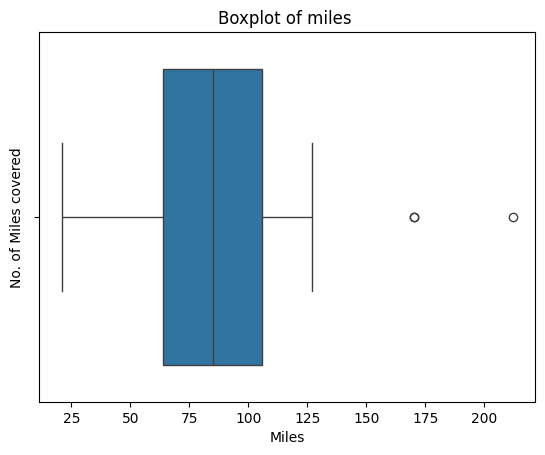

In [ ]:
sns.boxplot(x='Miles',  data=prod_KP481)
plt.title('Boxplot of miles ')
plt.xlabel('Miles')
plt.ylabel('No. of Miles covered')
plt.show()


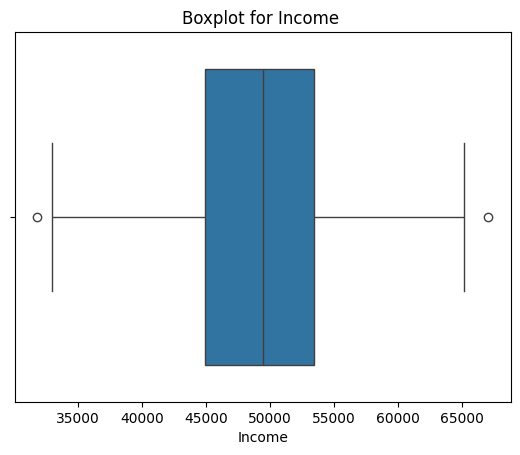

In [ ]:
sns.boxplot(x='Income',  data=prod_KP481)
plt.title('Boxplot for Income ')
plt.xlabel('Income')
# plt.ylabel('No. of Miles covered')
plt.show()


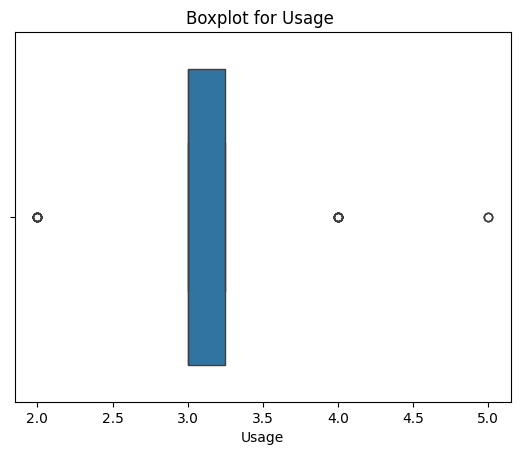

In [ ]:
sns.boxplot(x='Usage',  data=prod_KP481)
plt.title('Boxplot for Usage ')
plt.xlabel('Usage')
# plt.ylabel('No. of Miles covered')
plt.show()


###**Observations of Model KP481:**

*   Around 33.3% of people use this Product model KP481.
*   In which the probability of a male is around 0.51 and a female is 0.48.
*   This model is widely used by the age group (20-40), we can see this is
    popular among the Prime working age Adults, holding 80% of the data.
*   60% of the users who bought this are married .
*   Their maximun usage is around 3 times per week , which is also the average
    number of times used.
*   The people who bought this have annual income mostly in the range(40,500-60,000).
*   They rate themselves 3 in the fitness scale 0f 1-5, which is moderately fit.
*   Their average miles covered is 87.9 , while most people cover 95 miles per week.
*   They tend to excersice more when compared to people who use beginner model.
*   The outliers present are comparatively less .














##**KP781**

In [ ]:
# Check the shape of the prod_KP781 DataFrame
prod_KP781.shape

(40, 9)

In [ ]:
prod_KP781.sample(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,age_group
150,KP781,25,Male,16,Partnered,4,5,49801,120,21-30
165,KP781,29,Male,18,Single,5,5,52290,180,21-30
173,KP781,35,Male,16,Partnered,4,5,92131,360,31-40
164,KP781,28,Male,18,Single,6,5,88396,150,21-30
161,KP781,27,Male,21,Partnered,4,4,90886,100,21-30
167,KP781,30,Female,16,Partnered,6,5,90886,280,31-40
158,KP781,26,Male,16,Partnered,5,4,64741,180,21-30
178,KP781,47,Male,18,Partnered,4,5,104581,120,41-50
168,KP781,30,Male,18,Partnered,5,4,103336,160,31-40
144,KP781,23,Female,18,Single,5,4,53536,100,21-30


In [ ]:
prod_KP781['Gender'].value_counts()

,count
Gender,
Male,33
Female,7


In [ ]:
# Finding the probability of each gender
prob_male_purchase_prod_KP781=prod_KP781['Gender'].value_counts().loc['Male']/len(prod_KP781)
prob_female_purchase_prod_KP781=1-prob_male_purchase_prod_KP781
print('Probability of male that purchased KP781 : ',prob_male_purchase_prod_KP781)
print('Probability of female that purchased KP781 : ',prob_female_purchase_prod_KP781)

Probability of male that purchased KP781 :  0.825
Probability of female that purchased KP781 :  0.17500000000000004


In [ ]:
# grouping age
prod_KP781.loc[:, 'age_group'] = pd.cut(prod_KP781['Age'], bins=bins, labels=labels, right=False)

In [ ]:
# using pandas crosstab
pd.crosstab(index=prod_KP781['Gender'], columns=prod_KP781['age_group'])


age_group,21-30,31-40,41-50
Gender,,,
Female,5,2,0
Male,22,6,5


In [ ]:
#probability of most age group using it
age_bins = pd.cut(prod_KP781['Age'], bins=[10,20, 30, 40, 50])
age_counts = age_bins.value_counts().sort_index()
max_group = age_counts.idxmax()
max_count = age_counts.max()
prob = max_count / len(prod_KP781)

print(f"The most common age group is {max_group}, with probability {prob:.2f}")


The most common age group is (20, 30], with probability 0.75


In [ ]:
prod_KP781['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,23
Single,17


In [ ]:
# Probability of marital status
prob_partnered_KP781=prod_KP781['MaritalStatus'].value_counts().loc['Partnered']/len(prod_KP781)
prob_single_KP781=1-prob_partnered_KP781
print('Probability of people using KP781 and are married : ',prob_partnered_KP781)
# prob_single=1-prob_partnered
print('Probability of people using KP781 and are single : ',prob_single_KP781)

Probability of people using KP781 and are married :  0.575
Probability of people using KP781 and are single :  0.42500000000000004


In [ ]:
prod_KP781['Usage'].value_counts()

,count
Usage,
4,18
5,12
6,7
7,2
3,1


In [ ]:
# Average number of times it is used in a week
print('max count of usage',prod_KP781['Usage'].mode())
print('Average time people use : ',prod_KP781['Usage'].mean())

max count of usage 0    4
Name: Usage, dtype: int64
Average time people use :  4.775


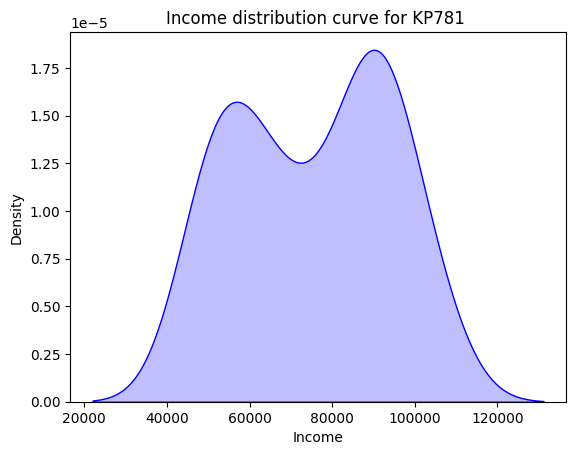

In [ ]:
prod_KP781['Income'].value_counts()
raw_data = prod_KP781['Income'].value_counts().index.repeat(prod_KP781['Income'].value_counts().values)
sns.kdeplot(raw_data, fill=True,color='blue')
plt.title('Income distribution curve for KP781 ')
plt.xlabel('Income')
plt.ylabel('Density')
plt.show()

In [ ]:
prod_KP781['Fitness'].value_counts()

,count
Fitness,
5,29
4,7
3,4


In [ ]:
# Most rated fitness among users
prod_KP781['Fitness'].value_counts()
print('The average Fitness : ',prod_KP781['Fitness'].mean())
print('The maximun fitness among users : ',prod_KP781['Fitness'].mode())

The average Fitness :  4.625
The maximun fitness among users :  0    5
Name: Fitness, dtype: int64


In [ ]:
prod_KP781['Miles'].value_counts()

,count
Miles,
100,7
200,6
180,6
160,5
150,4
120,3
106,1
80,1
140,1


In [ ]:
print('The mean of Miles covered in a week : ',prod_KP781['Miles'].mean())
print('The max number of Miles covered in a week by most users : ',prod_KP781['Miles'].mode())

The mean of Miles covered in a week :  166.9
The max number of Miles covered in a week by most users :  0    100
Name: Miles, dtype: int64


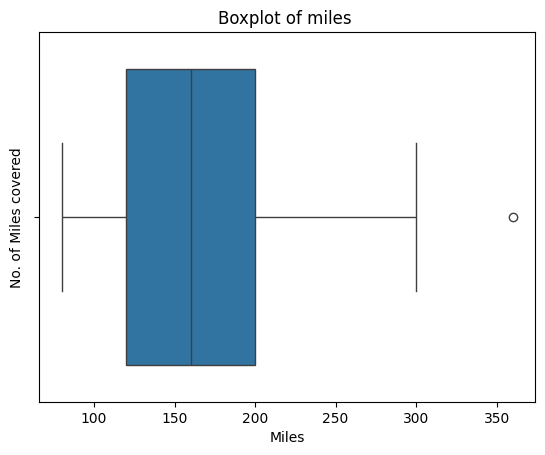

In [ ]:
sns.boxplot(x='Miles',  data=prod_KP781)
plt.title('Boxplot of miles ')
plt.xlabel('Miles')
plt.ylabel('No. of Miles covered')
plt.show()


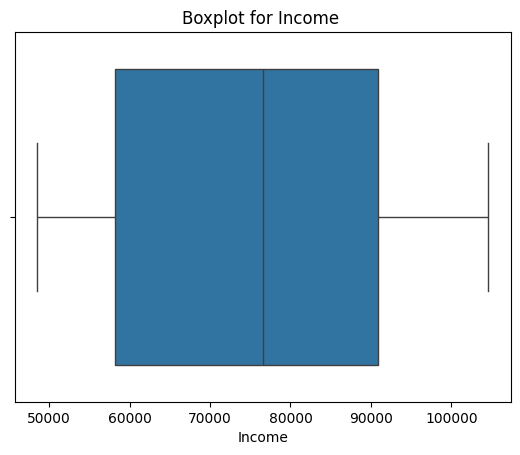

In [ ]:
sns.boxplot(x='Income',  data=prod_KP781)
plt.title('Boxplot for Income ')
plt.xlabel('Income')
# plt.ylabel('No. of Miles covered')
plt.show()


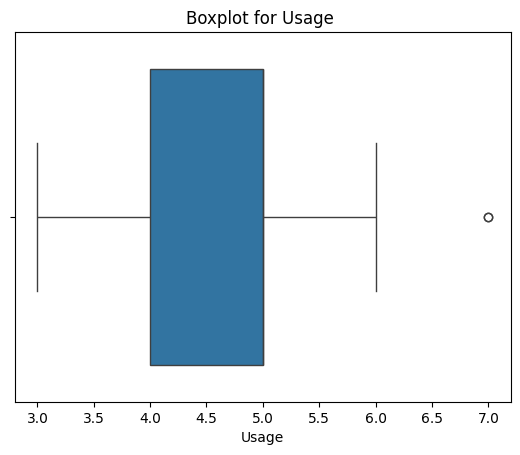

In [ ]:
sns.boxplot(x='Usage',  data=prod_KP781)
plt.title('Boxplot for Usage ')
plt.xlabel('Usage')
# plt.ylabel('No. of Miles covered')
plt.show()


###**Observations of Model KP781:**

*   Only 22% of people use this Product model KP781.
*   In which the probability of a male is maximum 0.82 and a female is only 0.17.
*   This model is widely used by the age group (20-30), we can see this is
    popular among the Young Adults, holding 78% of the data.
*   57% of the users who bought this are married .
*   Their maximun usage is around 4 times per week , and average of 4.7
     times used.
*   The people who bought this have annual income mostly in the range(40,500-11,0000).
*   Maximum number of people have rated fitness 5 while average of people have 4.6 , stating this group of people are extensively fit .
*   while most people cover 100 miles per week , their average miles covered in a week is 166.
*   These group of people who have advanced features of treadmill tend to excersice most of all other group of users.
*   The outliers present are comparatively less when compared to all other groups.














##**Recommendations**



*   Users who are beginners to fitness, who are hoping to cover around 80-82 miles per week , looking for treadmill , without much features and will be using maximum 3 times per week should proceed buying the KP281 model as it also comes with the minimum budget . It is ideal for the usage of beginner young adults, irrespective of any gender.
*   While the people who are in prime working age , searching for fitness goal with some advanced features ,willing to cover around 87 miles on an average per week , and are ready to invest a little higher amount than the minimum price, should go with KP481 . This is most used by the males comparatively.
* The advanced featured treadmill KP781 are for those, who are fitness freak , among the working Adults . Probably male users,who have fitness rated 5 , and are going to use this around 4.7 times per week . On an average they cover around 100 miles per week , and have annual income mostly between 40,500-110000.



